In [30]:
import json
from urllib.request import Request, urlopen

resourceId = "M920141"

hdr = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json"
}

url = f"https://tablebuilder.singstat.gov.sg/api/table/tabledata/{resourceId}"

request = Request(url, headers=hdr)

with urlopen(request) as response:
    data = json.load(response)

#print(data)

In [35]:
import pandas as pd

rows = data["Data"]["row"]

records = []

for row in rows:
    category = row["rowText"]      # Total, Male, Female

    for item in row["columns"]:
        records.append({
            "Sex": category,
            "Year": int(item["key"]),
            "Value": float(item["value"])
        })

df = pd.DataFrame(records)

print(df.tail())

       Sex  Year  Value
43  Female  2020  879.3
44  Female  2021  913.0
45  Female  2022  940.8
46  Female  2023  953.8
47  Female  2024  965.3


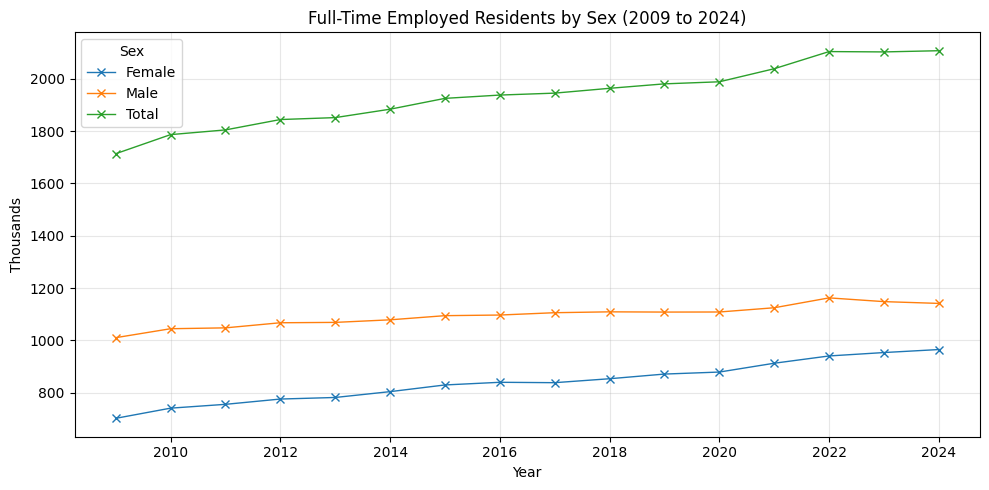

In [46]:
import matplotlib.pyplot as plt

# Convert long -> wide
plot_df = df.pivot(
    index="Year",
    columns="Sex",
    values="Value"
)

# Plot
ax = plot_df.plot(
    figsize=(10, 5),
    marker="x",
    linewidth=1
)

ax.set_title("Full-Time Employed Residents by Sex (2009 to 2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Thousands")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
plot_df

Sex,Female,Male,Total
Year,,,
2009,702.5,1010.6,1713.2
2010,741.4,1044.8,1786.2
2011,756.0,1048.1,1804.2
2012,776.2,1067.6,1843.8
2013,782.2,1069.0,1851.2
2014,804.5,1078.8,1883.3
2015,830.0,1094.7,1924.7
2016,840.2,1097.1,1937.3
2017,838.7,1106.0,1944.7
